# SRGAN on Kaggle — **Tesla P100** (64×64 → 224×224)

This notebook trains a **Super-Resolution GAN** that maps 64×64 LR images to 256×256 HR images at scale ×4, then resizes to 224×224 for delivery. Use it to upscale the images produced by your DCGAN/WGAN-GP runs while preserving (and enhancing) detail.

**Required Kaggle setup**
* Settings → **Accelerator: GPU P100**
* Settings → **Internet: ON** (so VGG19 perceptual weights can download)
* Datasets to add (left sidebar → *Add Data*):
    * **Required:** `abdelrahman0211/train-dataset-original` (your existing 224×224 X-rays — same one used by `kaggle_dcgan_top5.py` / `kaggle_wgan_gp_p100.ipynb`).
    * **Optional (for inference on your existing GAN outputs):** a dataset whose root contains a `generated_images/` folder with 64×64 PNGs in `grade0/ … grade4/` subfolders. Auto-detected at any of:
        * `/kaggle/input/gan-generated-64/generated_images`
        * `/kaggle/input/gan-generated-64`
        * `/kaggle/input/local-outputs/generated_images`

**Workflow**

1. Run the **pip install** cell once per fresh session (downgrades torch to a CUDA 11.8 wheel that includes Pascal/sm_60 kernels).
2. **Restart the session** (*Session → Restart Session*).
3. Run from **Verify CUDA** straight through to **Zip outputs**.

Output goes to `/kaggle/working/srgan/` and is bundled into `/kaggle/working/srgan_outputs.zip` for download.


## 1. Install PyTorch with Pascal (sm_60) support

Default Kaggle torch wheels target sm_70+; on a P100 (6.0) they fail with `CUDA error: no kernel image is available for execution on the device`. This cell pulls a CUDA 11.8 build that includes Pascal kernels.

Run **once** per session, then **restart** the session.

In [ ]:
import subprocess
import sys

def _run(cmd):
    print(" ", " ".join(cmd), flush=True)
    subprocess.check_call(cmd)

_run([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
_run([sys.executable, "-m", "pip", "install", "--no-cache-dir", "--upgrade", "numpy<2"])
_run([
    sys.executable, "-m", "pip", "install", "--no-cache-dir",
    "torch==2.2.2", "torchvision==0.17.2",
    "--index-url", "https://download.pytorch.org/whl/cu118",
])
print("\nDone. Now: Session -> Restart Session, then continue with cell 2.")

## 2. Verify CUDA / P100

After the **session restart**, start here. Do **not** re-run the install cell.

In [2]:
import numpy as np
import torch

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch.from_numpy(np.zeros((1,), dtype=np.float32))
print("numpy bridge ok")

if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))
    x = torch.randn(1024, 1024, device="cuda")
    print("matmul ok:", float((x @ x)[0, 0]))
else:
    raise RuntimeError("CUDA not available -- check accelerator and restart.")

numpy: 1.26.4
torch: 2.2.2+cu118
cuda available: True
numpy bridge ok
device: Tesla P100-PCIE-16GB
capability: (6, 0)
matmul ok: 88.301025390625


## 3. Imports and configuration

In [3]:
import glob
import math
import os
import random
import shutil
from pathlib import Path
from typing import Iterable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms, utils as vutils
from tqdm.auto import tqdm

In [4]:
DATASET_DIR = Path(
    "/kaggle/input/datasets/abdelrahman0211/train-dataset-original/Original Dataset train"
)

GENERATED_DIR_CANDIDATES = [
    Path("/kaggle/input/datasets/abdelrahman0211/gan-generated-64/generated_images"),
    Path("/kaggle/input/gan-generated-64"),
    Path("/kaggle/input/local-outputs/generated_images"),
]
GENERATED_DIR = next((p for p in GENERATED_DIR_CANDIDATES if p.exists()), None)

OUTPUT_DIR  = Path("/kaggle/working/srgan")
MODELS_DIR  = OUTPUT_DIR / "models"
PREVIEW_DIR = OUTPUT_DIR / "previews"
SR_OUT_DIR  = OUTPUT_DIR / "sr_images"
ZIP_PATH    = Path("/kaggle/working/srgan_outputs.zip")
for d in (OUTPUT_DIR, MODELS_DIR, PREVIEW_DIR, SR_OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

GRADE_LABELS = {
    0: "Grade 0 (Healthy)",
    1: "Grade 1 (Doubtful)",
    2: "Grade 2 (Mild)",
    3: "Grade 3 (Moderate)",
    4: "Grade 4 (Severe)",
}


NUM_CHANNELS    = 1
HR_SIZE         = 256
LR_SIZE         = 64
SCALE           = 4
FINAL_SIZE      = 224

BATCH_SIZE      = 32
NUM_WORKERS     = 2

PRETRAIN_EPOCHS = 5
GAN_EPOCHS      = 50
PIXEL_LR        = 1e-4
GAN_LR_G        = 1e-4
GAN_LR_D        = 1e-4
BETAS           = (0.9, 0.999)

PIXEL_WEIGHT    = 1.0
ADV_WEIGHT      = 1e-3
VGG_WEIGHT      = 6e-3

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  cap={torch.cuda.get_device_capability(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("WARNING: no CUDA -- enable: Settings -> Accelerator -> GPU P100")

_PIN_MEMORY = device.type == "cuda"

print("DATASET_DIR  exists:", DATASET_DIR.exists())
print("GENERATED_DIR:", GENERATED_DIR)

GPU: Tesla P100-PCIE-16GB  cap=(6, 0)
DATASET_DIR  exists: True
GENERATED_DIR: /kaggle/input/datasets/abdelrahman0211/gan-generated-64/generated_images


## 4. Dataset (HR=256, LR=64, ×4 super-resolution)

In [5]:
class SRDataset(Dataset):
    def __init__(self, root=DATASET_DIR, hr_size=HR_SIZE, lr_size=LR_SIZE, channels=NUM_CHANNELS, augment=True):
        paths = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.JPG", "*.JPEG"):
            paths.extend(glob.glob(str(root / "*" / ext)))
        if not paths:
            raise RuntimeError(f"No images found under {root}")
        self.paths = sorted(paths)
        self.hr_size = hr_size
        self.lr_size = lr_size
        self.channels = channels
        tfs = [
            transforms.Grayscale(num_output_channels=channels),
            transforms.Resize(hr_size, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop(hr_size),
        ]
        if augment:
            tfs.append(transforms.RandomHorizontalFlip())
        tfs.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5] * channels, [0.5] * channels),
        ])
        self.hr_tf = transforms.Compose(tfs)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L" if self.channels == 1 else "RGB")
        hr = self.hr_tf(img)
        lr = F.interpolate(
            hr.unsqueeze(0), size=self.lr_size,
            mode="bicubic", align_corners=False, antialias=True,
        ).squeeze(0).clamp(-1, 1)
        return lr, hr

ds = SRDataset()
val_size = max(64, len(ds) // 50)
indices = list(range(len(ds))); random.Random(SEED).shuffle(indices)
val_ds = Subset(ds, indices[:val_size])
train_ds = Subset(ds, indices[val_size:])

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=_PIN_MEMORY,
    drop_last=True, persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=_PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)
print(f"total HR={len(ds)}  train={len(train_ds)}  val={len(val_ds)}")

total HR=5778  train=5663  val=115


## 5. Models

Generator (SRResNet, 16 residual blocks + 2× PixelShuffle), discriminator (SRGAN classifier head), and VGG19 `conv5_4` feature extractor for perceptual loss.

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(ch)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        return x + self.bn2(self.conv2(self.prelu(self.bn1(self.conv1(x)))))


class UpsampleBlock(nn.Module):
    def __init__(self, ch=64, factor=2):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch * factor * factor, 3, 1, 1)
        self.ps = nn.PixelShuffle(factor)
        self.prelu = nn.PReLU()
    def forward(self, x):
        return self.prelu(self.ps(self.conv(x)))


class Generator(nn.Module):
    def __init__(self, in_ch=NUM_CHANNELS, n_blocks=16, ch=64, scale=SCALE):
        super().__init__()
        assert (scale & (scale - 1)) == 0, "scale must be a power of 2"
        self.head = nn.Sequential(nn.Conv2d(in_ch, ch, 9, 1, 4), nn.PReLU())
        self.body = nn.Sequential(*[ResidualBlock(ch) for _ in range(n_blocks)])
        self.body_tail = nn.Sequential(nn.Conv2d(ch, ch, 3, 1, 1), nn.BatchNorm2d(ch))
        ups, s = [], scale
        while s > 1:
            ups.append(UpsampleBlock(ch, factor=2)); s //= 2
        self.upsampler = nn.Sequential(*ups)
        self.tail = nn.Conv2d(ch, in_ch, 9, 1, 4)
    def forward(self, x):
        h = self.head(x); b = self.body(h); b = self.body_tail(b) + h
        return torch.tanh(self.tail(self.upsampler(b)))


class _DBlock(nn.Module):
    def __init__(self, in_c, out_c, stride):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, stride, 1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, in_ch=NUM_CHANNELS):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, 1, 1), nn.LeakyReLU(0.2, inplace=True),
            _DBlock(64, 64, 2), _DBlock(64, 128, 1),
            _DBlock(128, 128, 2), _DBlock(128, 256, 1),
            _DBlock(256, 256, 2), _DBlock(256, 512, 1),
            _DBlock(512, 512, 2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1),
        )
    def forward(self, x):
        return self.layers(x)


class VGGFeat(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        except TypeError:
            vgg = models.vgg19(pretrained=True).features
        self.feat = nn.Sequential(*list(vgg.children())[:36]).eval()
        for p in self.feat.parameters():
            p.requires_grad = False
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def forward(self, x):
        x = (x + 1.0) / 2.0
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        return self.feat((x - self.mean) / self.std)

G = Generator().to(device)
D = Discriminator().to(device)
print(f"Generator     params: {sum(p.numel() for p in G.parameters())/1e6:.2f}M")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters())/1e6:.2f}M")

Generator     params: 1.53M
Discriminator params: 5.21M


## 6. Helpers (PSNR, previews, evaluation)

In [7]:
def denorm(t):
    return (t.clamp(-1, 1) + 1) / 2

def psnr(sr, hr, max_val=1.0):
    mse = F.mse_loss(denorm(sr), denorm(hr)).item()
    if mse <= 1e-10:
        return 99.0
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

def save_preview(lr, hr, sr, path, n=4):
    n = min(n, lr.size(0))
    lr_up = F.interpolate(lr[:n], size=hr.size(-1), mode="bicubic", align_corners=False)
    grid = torch.cat([denorm(lr_up), denorm(sr[:n]), denorm(hr[:n])], dim=0)
    vutils.save_image(grid, str(path), nrow=n)

@torch.no_grad()
def evaluate(generator, loader, save_path=None):
    generator.eval()
    total, count = 0.0, 0
    saved = False
    for lr_imgs, hr_imgs in loader:
        lr_imgs = lr_imgs.to(device, non_blocking=True)
        hr_imgs = hr_imgs.to(device, non_blocking=True)
        sr = generator(lr_imgs)
        total += psnr(sr, hr_imgs) * lr_imgs.size(0)
        count += lr_imgs.size(0)
        if not saved and save_path is not None:
            save_preview(lr_imgs, hr_imgs, sr, save_path)
            saved = True
    return total / max(count, 1)

## 7. Pretrain SRResNet (pixel-MSE warmup)

Stabilises the generator before adversarial training. Set `PRETRAIN_EPOCHS = 0` in the config cell to skip.

In [8]:
mse = nn.MSELoss()
if PRETRAIN_EPOCHS > 0:
    print(f"--- Pretraining SRResNet for {PRETRAIN_EPOCHS} epoch(s) ---")
    opt_pre = optim.Adam(G.parameters(), lr=PIXEL_LR, betas=BETAS)
    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        G.train()
        running, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Pretrain {epoch}/{PRETRAIN_EPOCHS}")
        for lr_imgs, hr_imgs in pbar:
            lr_imgs = lr_imgs.to(device, non_blocking=True)
            hr_imgs = hr_imgs.to(device, non_blocking=True)
            sr = G(lr_imgs)
            loss = mse(sr, hr_imgs)
            opt_pre.zero_grad(set_to_none=True); loss.backward(); opt_pre.step()
            running += loss.item() * lr_imgs.size(0); seen += lr_imgs.size(0)
            pbar.set_postfix(mse=f"{running/seen:.4f}")
        val_psnr = evaluate(G, val_loader, PREVIEW_DIR / f"pretrain_e{epoch:02d}.png")
        print(f"Pretrain epoch {epoch}: val PSNR = {val_psnr:.2f} dB")
    torch.save(G.state_dict(), MODELS_DIR / "srresnet_pretrain.pth")
    print(f"Saved -> {MODELS_DIR / 'srresnet_pretrain.pth'}")

--- Pretraining SRResNet for 5 epoch(s) ---


Pretrain 1/5:   0%|          | 0/176 [00:00<?, ?it/s]

Pretrain epoch 1: val PSNR = 31.73 dB


Pretrain 2/5:   0%|          | 0/176 [00:00<?, ?it/s]

Pretrain epoch 2: val PSNR = 31.58 dB


...

Pretrain epoch 3: val PSNR = 33.63 dB


Pretrain 4/5:   0%|          | 0/176 [00:00<?, ?it/s]

Pretrain epoch 4: val PSNR = 34.97 dB


Pretrain 5/5:   0%|          | 0/176 [00:00<?, ?it/s]

Pretrain epoch 5: val PSNR = 35.33 dB
Saved -> /kaggle/working/srgan/models/srresnet_pretrain.pth


## 8. Full SRGAN training (pixel + adversarial + VGG perceptual)

In [9]:
vgg = VGGFeat().to(device).eval()
opt_g = optim.Adam(G.parameters(), lr=GAN_LR_G, betas=BETAS)
opt_d = optim.Adam(D.parameters(), lr=GAN_LR_D, betas=BETAS)
bce = nn.BCEWithLogitsLoss()

history = {k: [] for k in ("epoch", "d_loss", "g_loss", "pix", "per", "adv", "val_psnr")}
best_psnr = -1.0

for epoch in range(1, GAN_EPOCHS + 1):
    G.train(); D.train()
    e_d = e_g = e_pix = e_per = e_adv = 0.0
    batches = 0
    pbar = tqdm(train_loader, desc=f"SRGAN {epoch}/{GAN_EPOCHS}")
    for lr_imgs, hr_imgs in pbar:
        lr_imgs = lr_imgs.to(device, non_blocking=True)
        hr_imgs = hr_imgs.to(device, non_blocking=True)


        with torch.no_grad():
            sr_detached = G(lr_imgs)
        d_real = D(hr_imgs); d_fake = D(sr_detached)
        d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
        opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()


        sr = G(lr_imgs)
        d_fake_g = D(sr)
        adv_loss = bce(d_fake_g, torch.ones_like(d_fake_g))
        pix_loss = mse(sr, hr_imgs)
        with torch.no_grad():
            hr_feat = vgg(hr_imgs)
        sr_feat = vgg(sr)
        per_loss = mse(sr_feat, hr_feat)
        g_loss = PIXEL_WEIGHT * pix_loss + ADV_WEIGHT * adv_loss + VGG_WEIGHT * per_loss
        opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()

        e_d += d_loss.item(); e_g += g_loss.item()
        e_pix += pix_loss.item(); e_per += per_loss.item(); e_adv += adv_loss.item()
        batches += 1
        pbar.set_postfix(
            d=f"{d_loss.item():.3f}", g=f"{g_loss.item():.3f}",
            pix=f"{pix_loss.item():.3f}", per=f"{per_loss.item():.3f}", adv=f"{adv_loss.item():.3f}",
        )

    val_psnr = evaluate(G, val_loader, PREVIEW_DIR / f"gan_e{epoch:02d}.png")
    history["epoch"].append(epoch)
    history["d_loss"].append(e_d / max(batches, 1))
    history["g_loss"].append(e_g / max(batches, 1))
    history["pix"].append(e_pix / max(batches, 1))
    history["per"].append(e_per / max(batches, 1))
    history["adv"].append(e_adv / max(batches, 1))
    history["val_psnr"].append(val_psnr)
    print(f"Epoch {epoch}: D={history['d_loss'][-1]:.3f}  G={history['g_loss'][-1]:.3f}  val PSNR={val_psnr:.2f} dB")

    if val_psnr > best_psnr:
        best_psnr = val_psnr
        torch.save({"G": G.state_dict(), "D": D.state_dict(), "epoch": epoch, "psnr": val_psnr},
                   MODELS_DIR / "srgan_best.pth")
        print("  -> new best, saved srgan_best.pth")

torch.save({"G": G.state_dict(), "D": D.state_dict()}, MODELS_DIR / "srgan_last.pth")
print(f"Done. Best val PSNR = {best_psnr:.2f} dB.")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:03<00:00, 161MB/s]  


SRGAN 1/50:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 1: D=1.196  G=0.003  val PSNR=36.31 dB
  -> new best, saved srgan_best.pth


SRGAN 2/50:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 2: D=1.398  G=0.002  val PSNR=36.24 dB


...

Epoch 48: D=1.328  G=0.002  val PSNR=37.78 dB


SRGAN 49/50:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 49: D=1.307  G=0.002  val PSNR=37.98 dB


SRGAN 50/50:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 50: D=1.351  G=0.002  val PSNR=38.50 dB
Done. Best val PSNR = 38.90 dB.


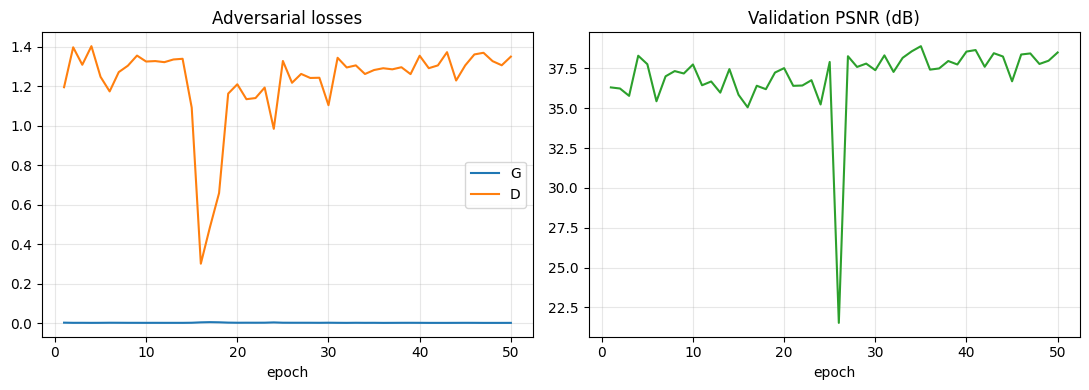

In [10]:
if history["epoch"]:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(history["epoch"], history["g_loss"], label="G")
    ax[0].plot(history["epoch"], history["d_loss"], label="D")
    ax[0].set_title("Adversarial losses"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(history["epoch"], history["val_psnr"], color="tab:green")
    ax[1].set_title("Validation PSNR (dB)"); ax[1].set_xlabel("epoch"); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=120); plt.show()

## 9. Load best generator for inference

In [11]:
for name in ("srgan_best.pth", "srgan_last.pth", "srresnet_pretrain.pth"):
    ckpt = MODELS_DIR / name
    if ckpt.exists():
        state = torch.load(ckpt, map_location=device)
        if isinstance(state, dict) and "G" in state:
            G.load_state_dict(state["G"])
            print(f"Loaded {name} (epoch {state.get('epoch','?')}, PSNR {state.get('psnr','?')})")
        else:
            G.load_state_dict(state)
            print(f"Loaded {name}")
        break
else:
    raise FileNotFoundError("No checkpoint found -- run the training cells first.")
G.eval();

Loaded srgan_best.pth (epoch 35, PSNR 38.897427356162524)


## 10. Inference helpers and bulk upscale
Reads every 64×64 image in the mounted `generated_images/grade*/` and writes 224×224 PNGs to `/kaggle/working/srgan/sr_images/`.

In [12]:
_INFER_TF = transforms.Compose([
    transforms.Grayscale(num_output_channels=NUM_CHANNELS) if NUM_CHANNELS == 1 else transforms.Lambda(lambda x: x),
    transforms.Resize(LR_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(LR_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * NUM_CHANNELS, [0.5] * NUM_CHANNELS),
])

@torch.no_grad()
def super_resolve_batch(images, generator=G, final_size=FINAL_SIZE):
    tensors = []
    for img in images:
        img = img.convert("L" if NUM_CHANNELS == 1 else "RGB")
        tensors.append(_INFER_TF(img))
    x = torch.stack(tensors).to(device, non_blocking=True)
    sr = generator(x)
    sr = denorm(sr).cpu().clamp(0, 1)
    out = []
    for t in sr:
        im = transforms.functional.to_pil_image(t)
        if im.size != (final_size, final_size):
            im = im.resize((final_size, final_size), Image.BICUBIC)
        out.append(im)
    return out

def upscale_directory(src_dir, dst_dir, generator=G, batch=16, max_count=None):
    src_dir = Path(src_dir); dst_dir = Path(dst_dir); dst_dir.mkdir(parents=True, exist_ok=True)
    files = sorted(list(src_dir.glob("*.png")) + list(src_dir.glob("*.jpg")) + list(src_dir.glob("*.jpeg")))
    if max_count is not None:
        files = files[:max_count]
    if not files:
        print(f"No images in {src_dir}"); return 0
    written = 0
    for i in tqdm(range(0, len(files), batch), desc=f"SR -> {dst_dir.name}"):
        chunk = files[i:i+batch]
        srs = super_resolve_batch([Image.open(p) for p in chunk], generator)
        for p, im in zip(chunk, srs):
            im.save(dst_dir / p.name); written += 1
    return written

totals = {}
if GENERATED_DIR is not None:
    grade_dirs = sorted(GENERATED_DIR.glob("grade*"))
    if not grade_dirs:
        grade_dirs = [GENERATED_DIR / str(g) for g in range(5) if (GENERATED_DIR / str(g)).exists()]
    for src in grade_dirs:
        dst = SR_OUT_DIR / src.name if src.name.startswith("grade") else SR_OUT_DIR / f"grade{src.name}"
        totals[dst.name] = upscale_directory(src, dst)
    print("Wrote:", totals)
    print("Output root:", SR_OUT_DIR)
else:
    print("No generated-images dataset mounted -- skipping bulk upscale.")
    print("To upscale anyway, call: upscale_directory(Path('/some/lr/folder'), SR_OUT_DIR/'custom')")

SR -> grade1:   0%|          | 0/78 [00:00<?, ?it/s]

SR -> grade2:   0%|          | 0/49 [00:00<?, ?it/s]

Wrote: {'grade1': 1240, 'grade2': 770}
Output root: /kaggle/working/srgan/sr_images


## 11. Visual comparison: LR vs bicubic vs SRGAN

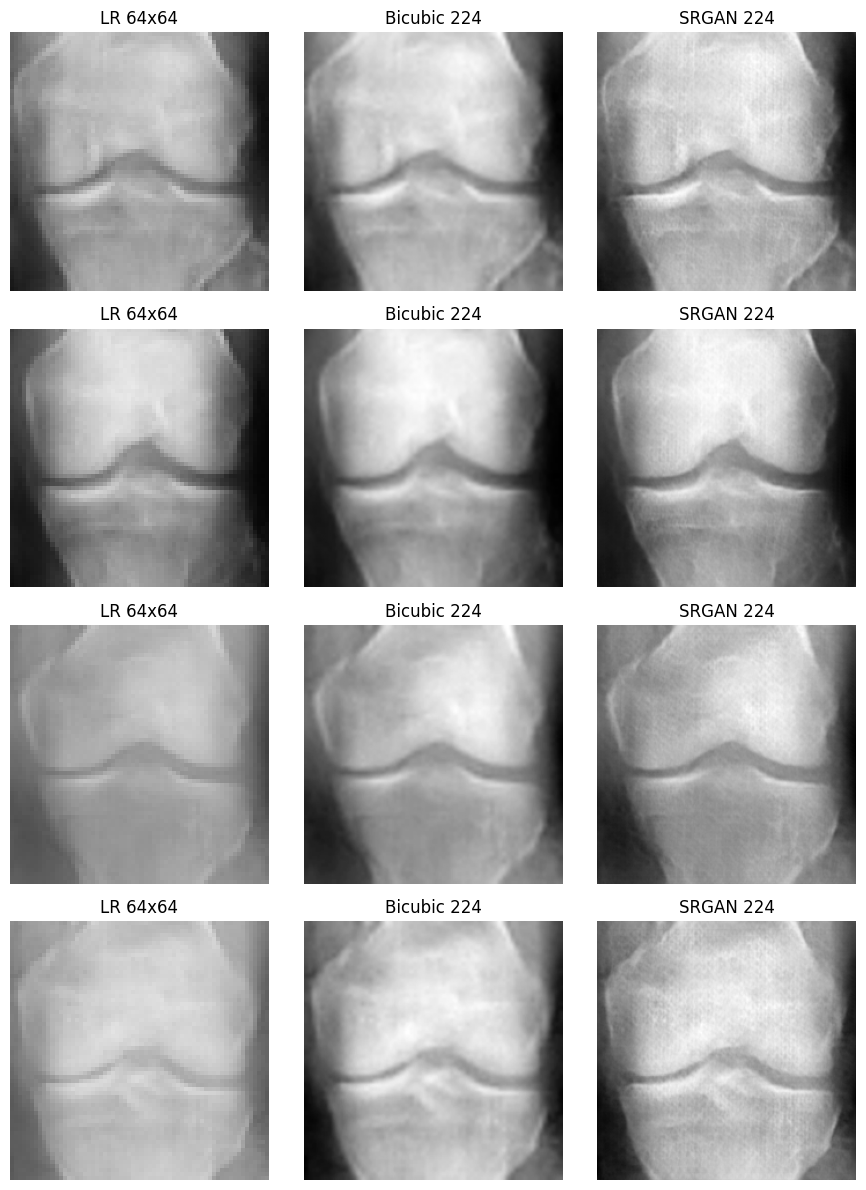

In [13]:
sample_dir = None
if GENERATED_DIR is not None:
    grade_dirs = sorted(GENERATED_DIR.glob("grade*")) or [GENERATED_DIR]
    sample_dir = grade_dirs[0]

if sample_dir is not None:
    files = sorted(list(sample_dir.glob("*.png")) + list(sample_dir.glob("*.jpg")))[:4]
    if files:
        fig, axes = plt.subplots(len(files), 3, figsize=(9, 3 * len(files)))
        if len(files) == 1:
            axes = np.expand_dims(axes, 0)
        for i, fp in enumerate(files):
            lr = Image.open(fp)
            bicubic = lr.convert("L").resize((FINAL_SIZE, FINAL_SIZE), Image.BICUBIC)
            sr = super_resolve_batch([lr], G)[0]
            for ax, im, title in zip(
                axes[i], [lr, bicubic, sr],
                [f"LR {lr.size[0]}x{lr.size[1]}", f"Bicubic {FINAL_SIZE}", f"SRGAN {FINAL_SIZE}"],
            ):
                ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
        plt.tight_layout(); plt.show()
    else:
        print(f"No images in {sample_dir}")
else:
    lr_imgs, hr_imgs = next(iter(val_loader))
    lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
    with torch.no_grad():
        sr = G(lr_imgs)
    n = min(4, lr_imgs.size(0))
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)
    lr_up = F.interpolate(lr_imgs[:n], size=hr_imgs.size(-1), mode="bicubic", align_corners=False)
    for i in range(n):
        ims = [denorm(t).cpu().squeeze().numpy() for t in (lr_up[i], sr[i], hr_imgs[i])]
        for ax, im, title in zip(axes[i], ims, ["Bicubic", "SRGAN", "HR"]):
            ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()

## 12. Quantitative check vs bicubic (validation split)

In [14]:
@torch.no_grad()
def compare_with_bicubic(loader):
    G.eval()
    sr_total, bic_total, n = 0.0, 0.0, 0
    for lr_imgs, hr_imgs in loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        sr = G(lr_imgs)
        bic = F.interpolate(lr_imgs, size=hr_imgs.size(-1), mode="bicubic", align_corners=False)
        sr_total  += psnr(sr, hr_imgs) * lr_imgs.size(0)
        bic_total += psnr(bic, hr_imgs) * lr_imgs.size(0)
        n += lr_imgs.size(0)
    return sr_total / n, bic_total / n

sr_p, bic_p = compare_with_bicubic(val_loader)
print(f"SRGAN   PSNR (val): {sr_p:.2f} dB")
print(f"Bicubic PSNR (val): {bic_p:.2f} dB")
print(f"Δ = {sr_p - bic_p:+.2f} dB")

SRGAN   PSNR (val): 38.90 dB
Bicubic PSNR (val): 39.24 dB
Δ = -0.34 dB


## 13. Zip outputs for download

Bundles `models/`, `previews/`, `training_curves.png`, and `sr_images/` into `/kaggle/working/srgan_outputs.zip`. After this finishes the zip appears in the notebook's *Output* tab — click it to download everything.

In [15]:
if ZIP_PATH.exists():
    ZIP_PATH.unlink()
archive = shutil.make_archive(
    str(ZIP_PATH.with_suffix("")), "zip",
    root_dir=str(OUTPUT_DIR.parent), base_dir=OUTPUT_DIR.name,
)
print("Wrote zip:", archive)

Wrote zip: /kaggle/working/srgan_outputs.zip
